In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold,
    GridSearchCV
)

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    VotingClassifier,
    StackingClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("Beans Multiclass Classification.csv")

In [3]:
df.head()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272751,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


In [4]:
df.shape

(13611, 17)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  str    
dtypes: float64(14), int64(2

In [6]:
df.describe()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
count,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000
mean,53048.284549,855.283459,320.141867,202.270714,1.583242,0.750895,53768.200206,253.064220,0.749733,0.987143,0.873282,0.799864,0.006564,0.001716,0.643590,0.995063
std,29324.095717,214.289696,85.694186,44.970091,0.246678,0.092002,29774.915817,59.177120,0.049086,0.004660,0.059520,0.061713,0.001128,0.000596,0.098996,0.004366
min,20420.000000,524.736000,183.601165,122.512653,1.024868,0.218951,20684.000000,161.243764,0.555315,0.919246,0.489618,0.640577,0.002778,0.000564,0.410339,0.947687
25%,36328.000000,703.523500,253.303633,175.848170,1.432307,0.715928,36714.500000,215.068003,0.718634,0.985670,0.832096,0.762469,0.005900,0.001154,0.581359,0.993703
50%,44652.000000,794.941000,296.883367,192.431733,1.551124,0.764441,45178.000000,238.438026,0.759859,0.988283,0.883157,0.801277,0.006645,0.001694,0.642044,0.996386
75%,61332.000000,977.213000,376.495012,217.031741,1.707109,0.810466,62294.000000,279.446467,0.786851,0.990013,0.916869,0.834270,0.007271,0.002170,0.696006,0.997883
max,254616.000000,1985.370000,738.860154,460.198497,2.430306,0.911423,263261.000000,569.374358,0.866195,0.994677,0.990685,0.987303,0.010451,0.003665,0.974767,0.999733


In [7]:
df["Class"].value_counts()

Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64

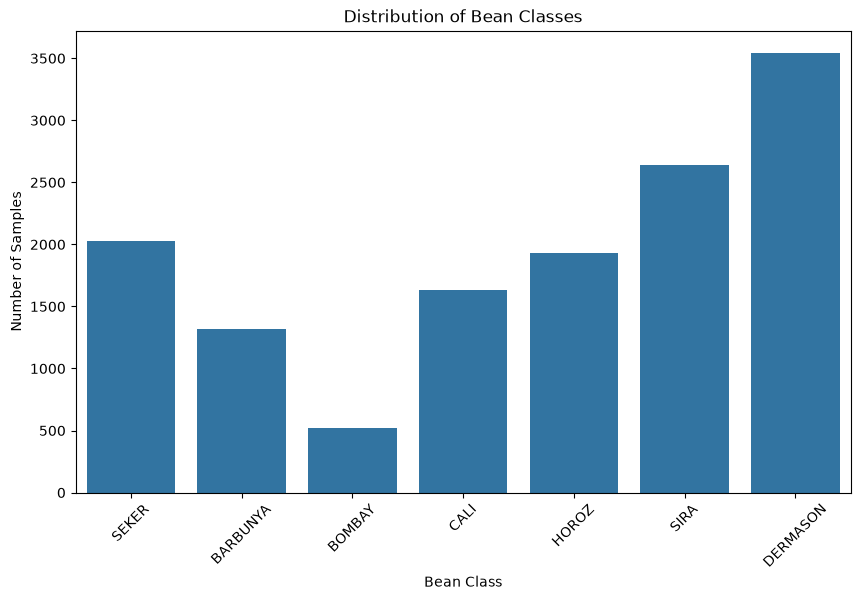

In [8]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="Class"
)

plt.title("Distribution of Bean Classes")
plt.xlabel("Bean Class")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)

plt.show()

In [9]:
class_percentage = (
    df["Class"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

class_percentage

Class
DERMASON    26.05
SIRA        19.37
SEKER       14.89
HOROZ       14.17
CALI        11.98
BARBUNYA     9.71
BOMBAY       3.84
Name: proportion, dtype: float64

In [10]:
numeric_features = df.select_dtypes(
    include=np.number
).columns.tolist()

numeric_features

['Area',
 'Perimeter',
 'MajorAxisLength',
 'MinorAxisLength',
 'AspectRation',
 'Eccentricity',
 'ConvexArea',
 'EquivDiameter',
 'Extent',
 'Solidity',
 'roundness',
 'Compactness',
 'ShapeFactor1',
 'ShapeFactor2',
 'ShapeFactor3',
 'ShapeFactor4']

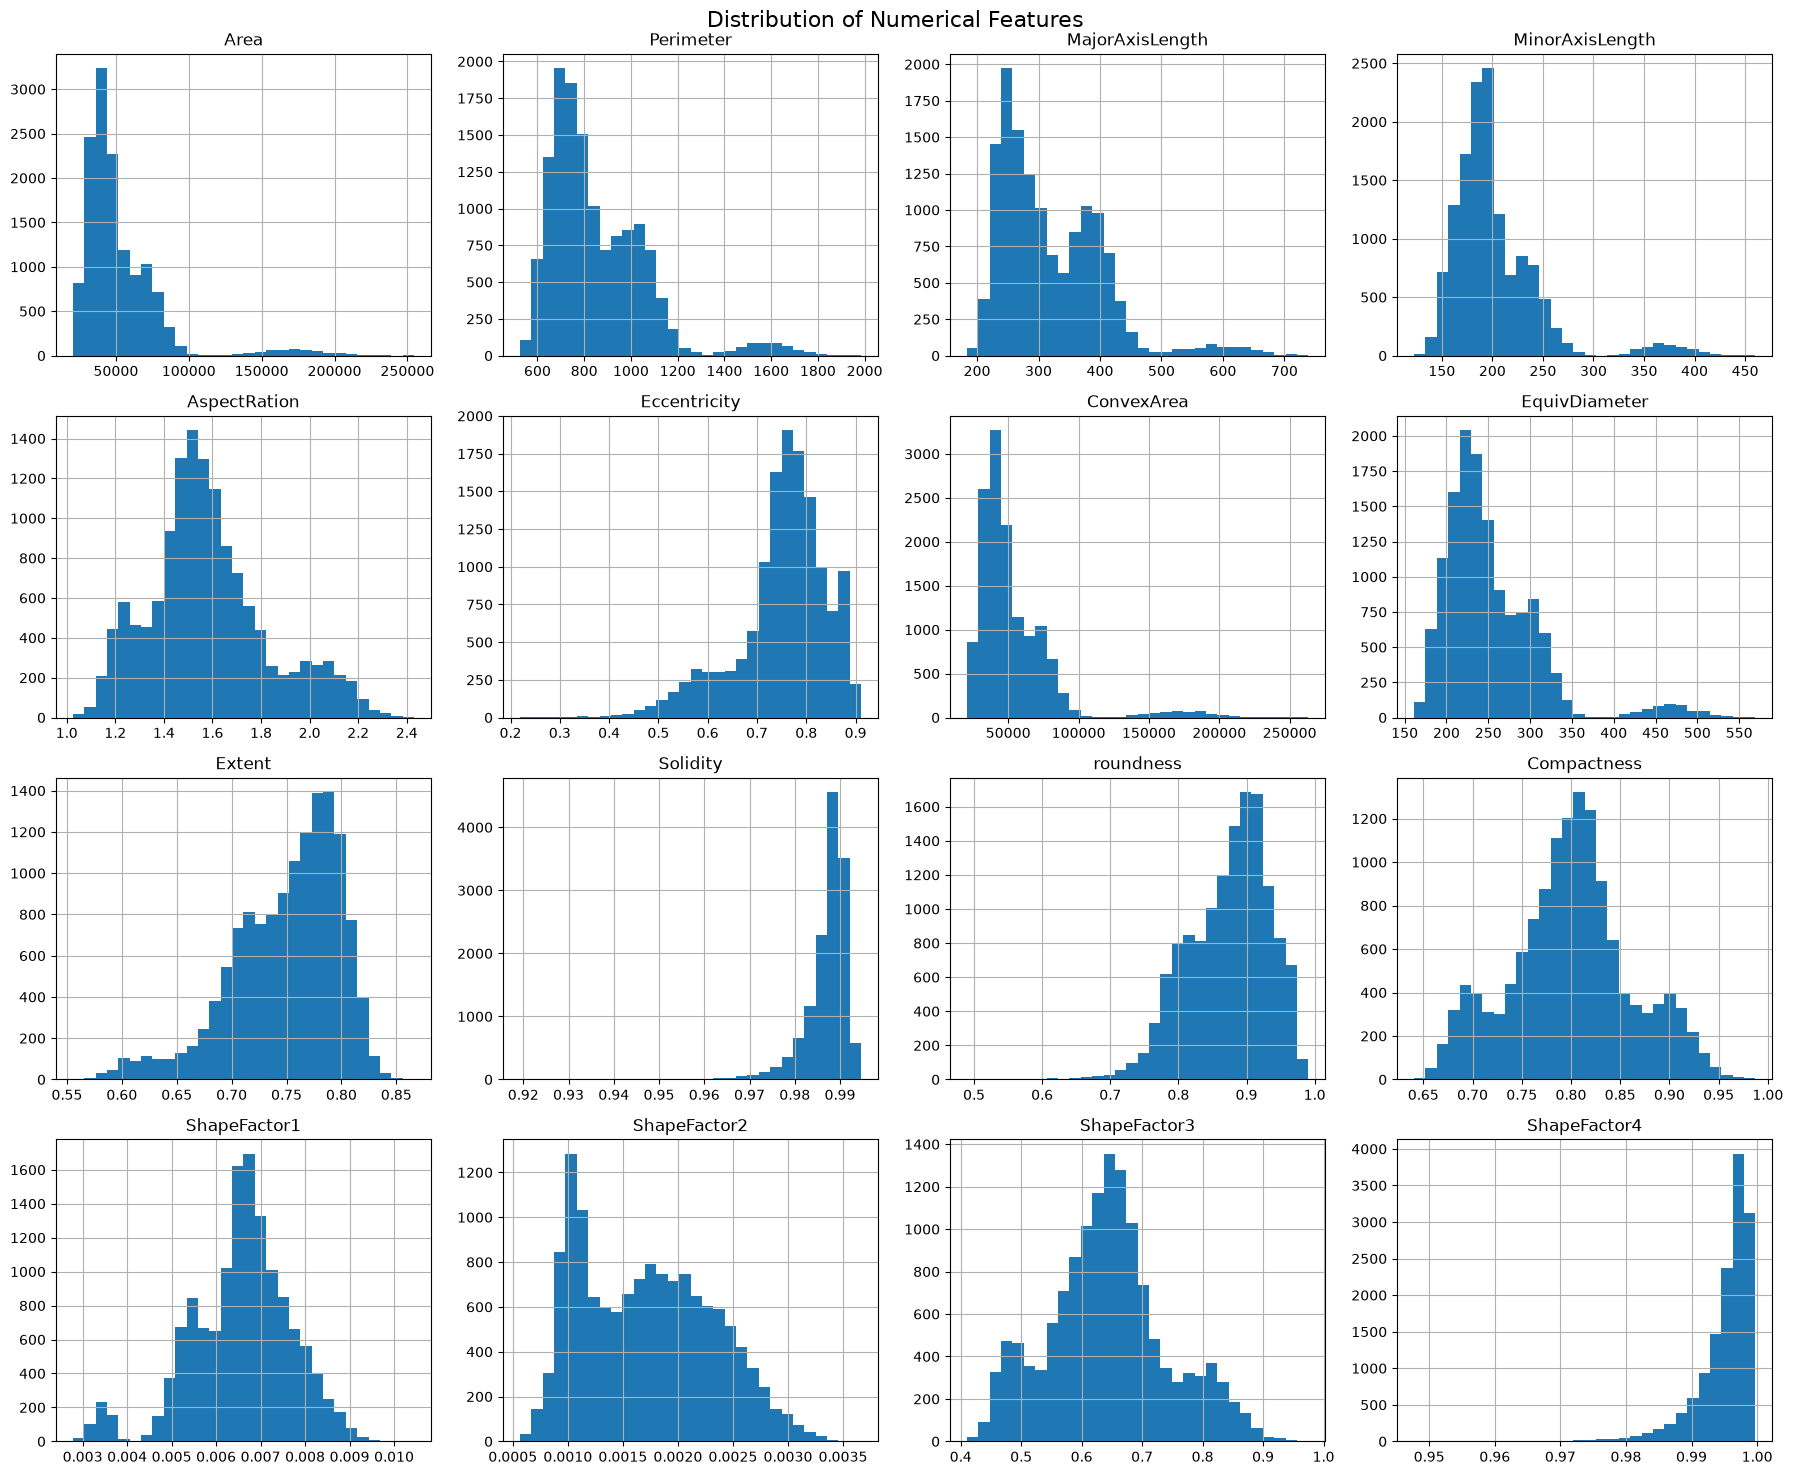

In [11]:
df[numeric_features].hist(
    figsize=(18, 15),
    bins=30
)

plt.suptitle(
    "Distribution of Numerical Features",
    fontsize=16
)

plt.tight_layout()
plt.show()

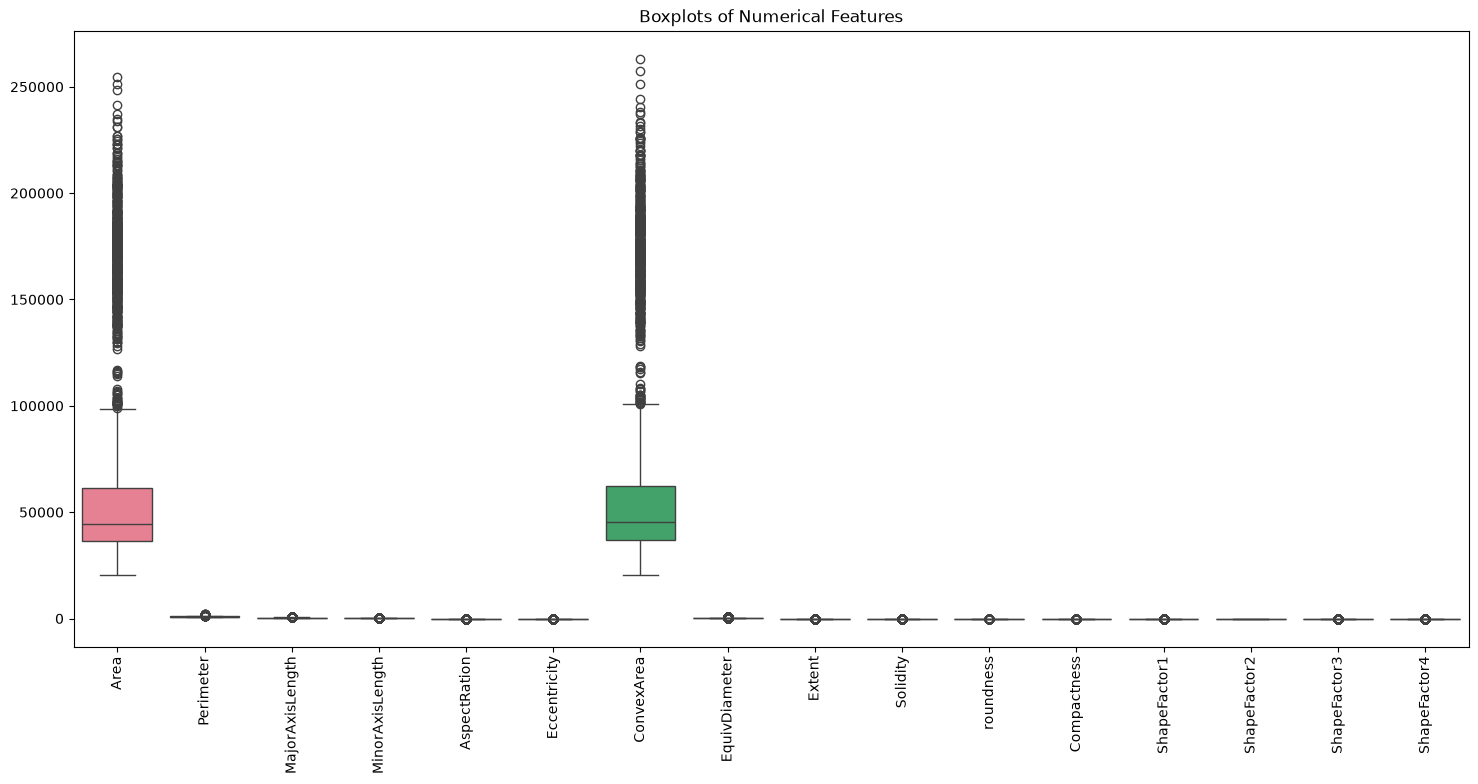

In [12]:
plt.figure(figsize=(18, 8))

sns.boxplot(
    data=df[numeric_features]
)

plt.xticks(rotation=90)
plt.title("Boxplots of Numerical Features")

plt.show()

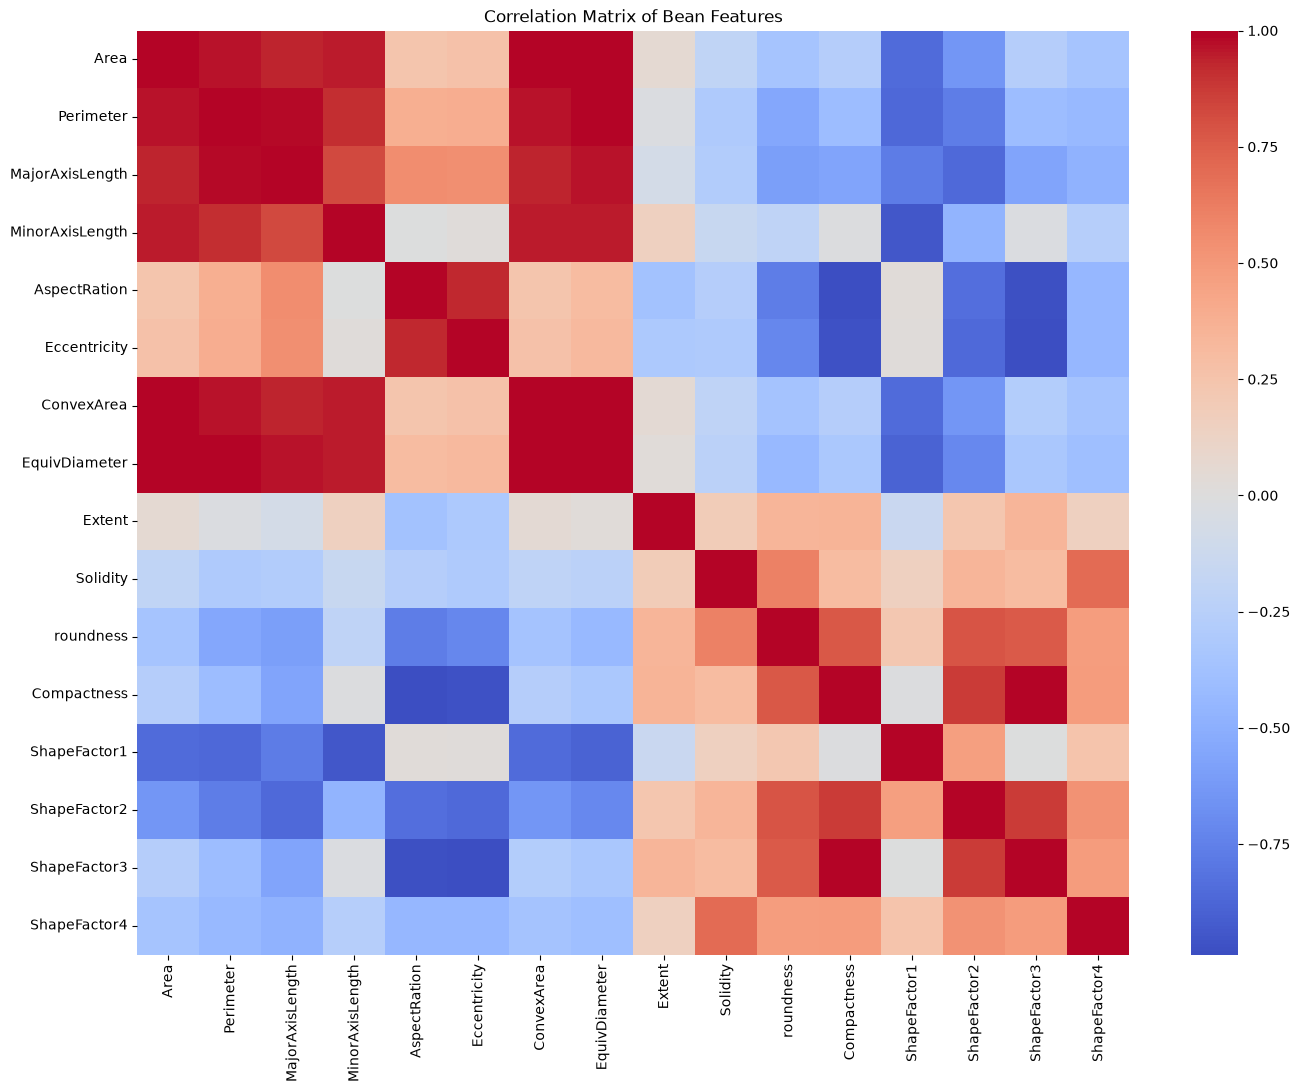

In [13]:
correlation_matrix = df[numeric_features].corr()

plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Bean Features")

plt.show()

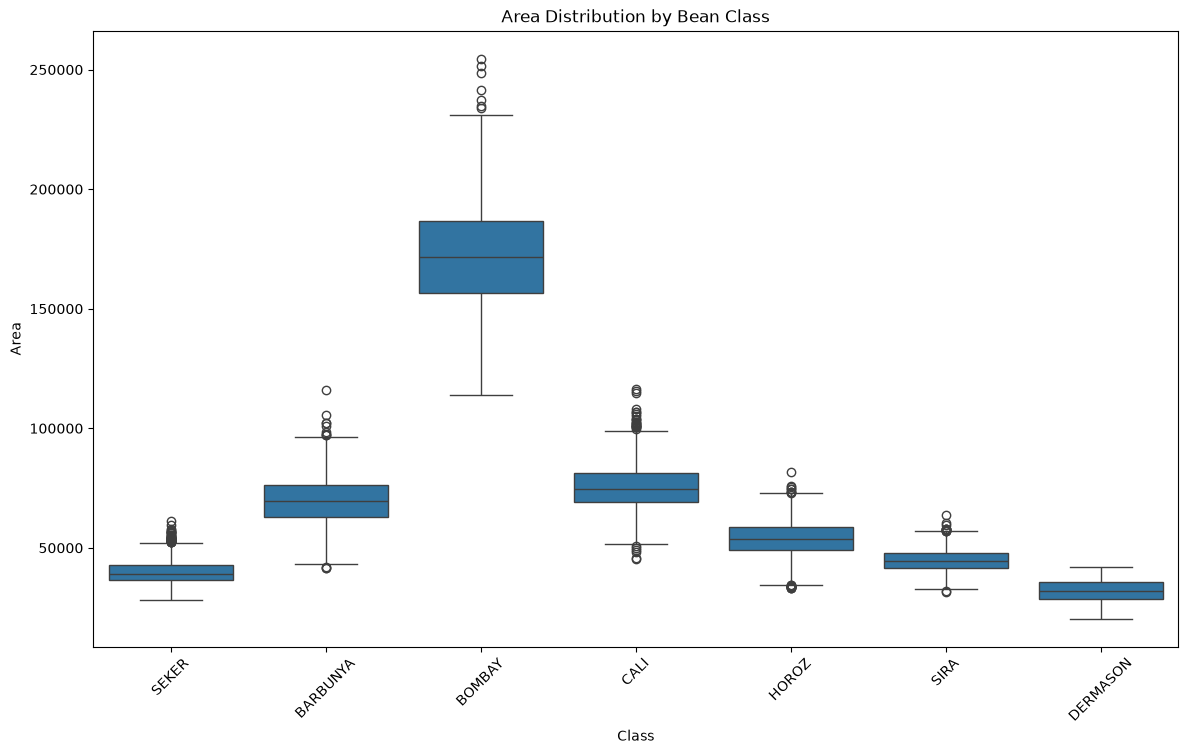

In [14]:
plt.figure(figsize=(14, 8))

sns.boxplot(
    data=df,
    x="Class",
    y="Area"
)

plt.xticks(rotation=45)
plt.title("Area Distribution by Bean Class")

plt.show()

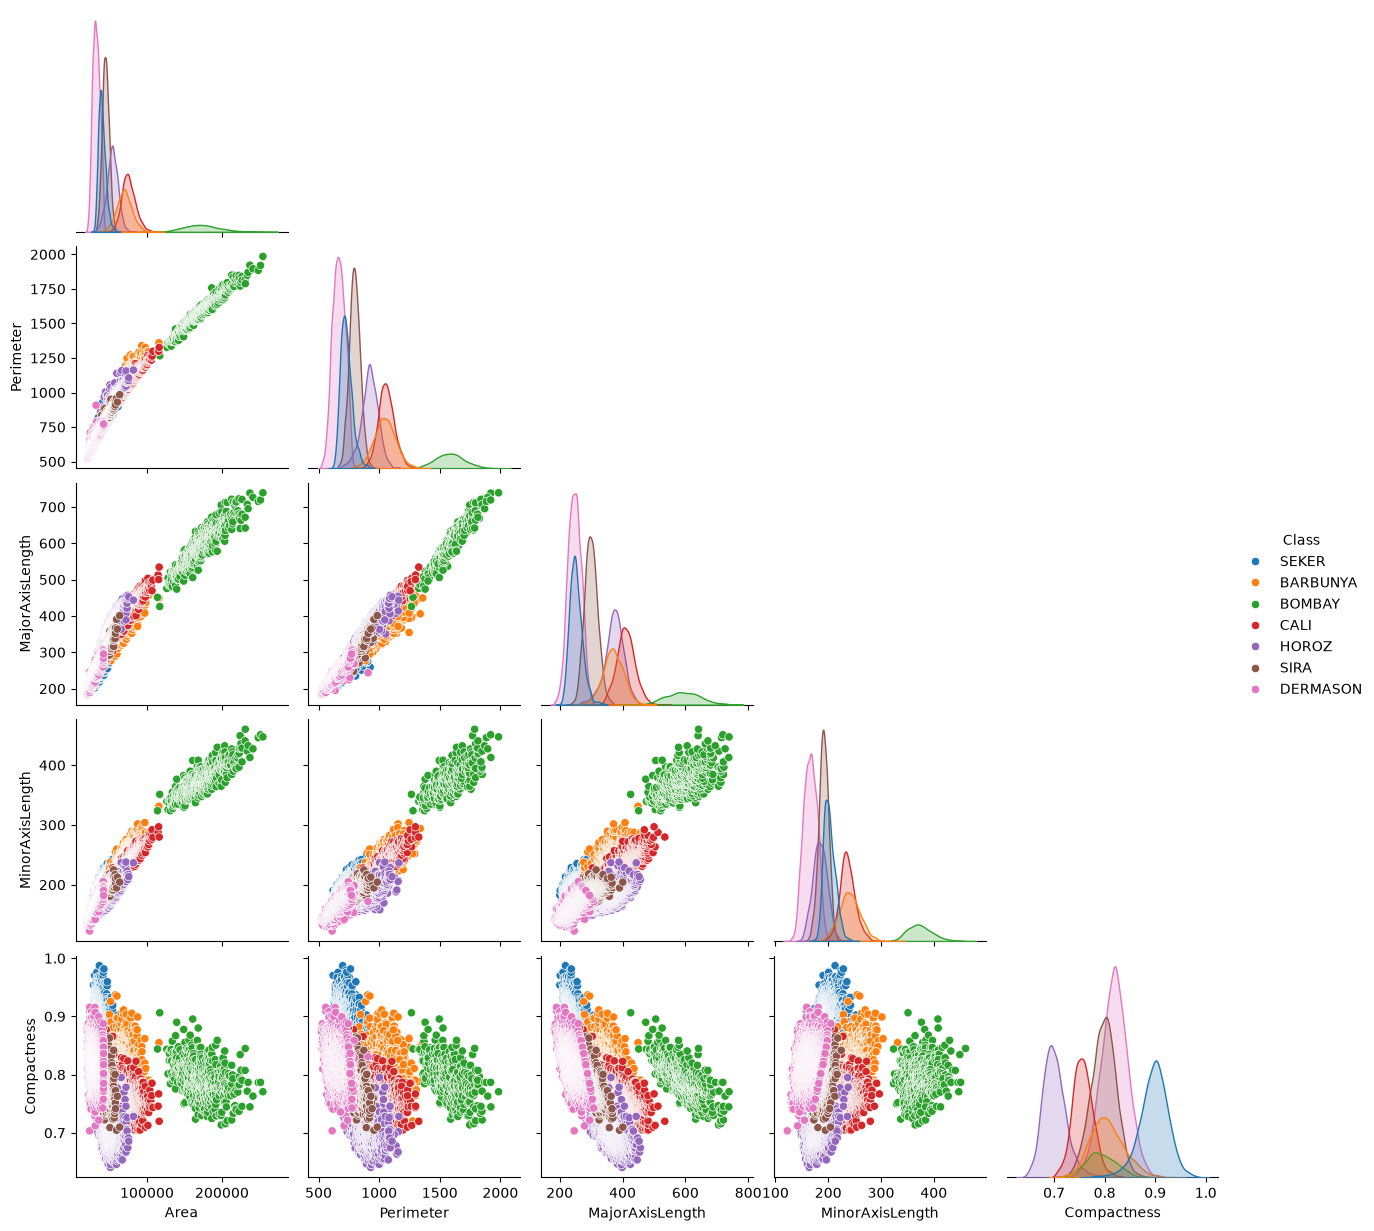

In [15]:
selected_features = [
    "Area",
    "Perimeter",
    "MajorAxisLength",
    "MinorAxisLength",
    "Compactness"
]

sns.pairplot(
    df[selected_features + ["Class"]],
    hue="Class",
    corner=True
)

plt.show()

In [16]:
df.isnull().sum()

Area               0
Perimeter          0
MajorAxisLength    0
MinorAxisLength    0
AspectRation       0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Solidity           0
roundness          0
Compactness        0
ShapeFactor1       0
ShapeFactor2       0
ShapeFactor3       0
ShapeFactor4       0
Class              0
dtype: int64

In [17]:
df.duplicated().sum()

np.int64(68)

In [18]:
df.drop_duplicates(inplace=True)

In [19]:
Q1 = df[numeric_features].quantile(0.25)

Q3 = df[numeric_features].quantile(0.75)

IQR = Q3 - Q1

In [20]:
lower_bound = Q1 - 1.5 * IQR

upper_bound = Q3 + 1.5 * IQR

outlier_mask = (
    (df[numeric_features] < lower_bound) |
    (df[numeric_features] > upper_bound)
)

outlier_counts = outlier_mask.sum()

outlier_counts.sort_values(ascending=False)

Eccentricity       833
Solidity           774
ShapeFactor4       760
MinorAxisLength    567
Area               551
ConvexArea         549
ShapeFactor1       533
EquivDiameter      526
Perimeter          500
AspectRation       485
MajorAxisLength    379
Extent             271
ShapeFactor3       202
Compactness        124
roundness           98
ShapeFactor2         0
dtype: int64

In [21]:
X = df.drop("Class", axis=1)

y = df["Class"]

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [23]:
logistic_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    (
        "model",
        LogisticRegression(
            max_iter=2000,
            random_state=42
        )
    )
])

logistic_pipeline.fit(X_train, y_train)

y_train_pred_lr = logistic_pipeline.predict(X_train)
y_test_pred_lr = logistic_pipeline.predict(X_test)

In [24]:
Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression())
])

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio)

In [25]:
dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train, y_train)

y_train_pred_dt = dt_model.predict(X_train)
y_test_pred_dt = dt_model.predict(X_test)

In [26]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_train_pred_rf = rf_model.predict(X_train)
y_test_pred_rf = rf_model.predict(X_test)

In [27]:
knn_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    (
        "model",
        KNeighborsClassifier(
            n_neighbors=5
        )
    )
])

knn_pipeline.fit(X_train, y_train)

y_train_pred_knn = knn_pipeline.predict(X_train)
y_test_pred_knn = knn_pipeline.predict(X_test)

In [28]:
svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    (
        "model",
        SVC(
            kernel="rbf",
            random_state=42
        )
    )
])

svm_pipeline.fit(X_train, y_train)

y_train_pred_svm = svm_pipeline.predict(X_train)
y_test_pred_svm = svm_pipeline.predict(X_test)

In [29]:
nb_model = GaussianNB()

nb_model.fit(X_train, y_train)

y_train_pred_nb = nb_model.predict(X_train)
y_test_pred_nb = nb_model.predict(X_test)

In [30]:
gb_model = GradientBoostingClassifier(
    random_state=42
)

gb_model.fit(X_train, y_train)

y_train_pred_gb = gb_model.predict(X_train)
y_test_pred_gb = gb_model.predict(X_test)

In [31]:
def evaluate_model(model_name, y_train, y_train_pred, y_test, y_test_pred):
    
    train_accuracy = accuracy_score(
        y_train,
        y_train_pred
    )
    
    test_accuracy = accuracy_score(
        y_test,
        y_test_pred
    )
    
    test_precision = precision_score(
        y_test,
        y_test_pred,
        average="weighted"
    )
    
    test_recall = recall_score(
        y_test,
        y_test_pred,
        average="weighted"
    )
    
    test_f1 = f1_score(
        y_test,
        y_test_pred,
        average="weighted"
    )
    
    return {
        "Model": model_name,
        "Train Accuracy": train_accuracy,
        "Test Accuracy": test_accuracy,
        "Precision": test_precision,
        "Recall": test_recall,
        "F1 Score": test_f1
    }

In [32]:
results = []

results.append(
    evaluate_model(
        "Logistic Regression",
        y_train,
        y_train_pred_lr,
        y_test,
        y_test_pred_lr
    )
)

results.append(
    evaluate_model(
        "Decision Tree",
        y_train,
        y_train_pred_dt,
        y_test,
        y_test_pred_dt
    )
)

results.append(
    evaluate_model(
        "Random Forest",
        y_train,
        y_train_pred_rf,
        y_test,
        y_test_pred_rf
    )
)

results.append(
    evaluate_model(
        "KNN",
        y_train,
        y_train_pred_knn,
        y_test,
        y_test_pred_knn
    )
)

results.append(
    evaluate_model(
        "SVM",
        y_train,
        y_train_pred_svm,
        y_test,
        y_test_pred_svm
    )
)

results.append(
    evaluate_model(
        "Naive Bayes",
        y_train,
        y_train_pred_nb,
        y_test,
        y_test_pred_nb
    )
)

results.append(
    evaluate_model(
        "Gradient Boosting",
        y_train,
        y_train_pred_gb,
        y_test,
        y_test_pred_gb
    )
)

In [33]:
results_df = pd.DataFrame(results)

results_df

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.926158,0.919528,0.920116,0.919528,0.919667
1,Decision Tree,1.000000,0.895533,0.895365,0.895533,0.895289
2,Random Forest,1.000000,0.919158,0.919191,0.919158,0.919102
3,KNN,0.942404,0.915467,0.916315,0.915467,0.915652
4,SVM,0.934189,0.921004,0.921411,0.921004,0.921078
5,Naive Bayes,0.763799,0.763012,0.764673,0.763012,0.760651
6,Gradient Boosting,0.964002,0.918420,0.918527,0.918420,0.918393


In [34]:
results_df["Accuracy Gap"] = (
    results_df["Train Accuracy"]
    - results_df["Test Accuracy"]
)

In [35]:
results_df

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score,Accuracy Gap
0,Logistic Regression,0.926158,0.919528,0.920116,0.919528,0.919667,0.006631
1,Decision Tree,1.000000,0.895533,0.895365,0.895533,0.895289,0.104467
2,Random Forest,1.000000,0.919158,0.919191,0.919158,0.919102,0.080842
3,KNN,0.942404,0.915467,0.916315,0.915467,0.915652,0.026937
4,SVM,0.934189,0.921004,0.921411,0.921004,0.921078,0.013185
5,Naive Bayes,0.763799,0.763012,0.764673,0.763012,0.760651,0.000787
6,Gradient Boosting,0.964002,0.918420,0.918527,0.918420,0.918393,0.045582


In [36]:
results_df["Overfitting"] = np.where(
    results_df["Accuracy Gap"] > 0.05,
    "Y",
    "N"
)

In [37]:
print(
    classification_report(
        y_test,
        y_test_pred_rf
    )
)

              precision    recall  f1-score   support

    BARBUNYA       0.92      0.89      0.90       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.92      0.93      0.93       326
    DERMASON       0.91      0.93      0.92       709
       HOROZ       0.96      0.94      0.95       372
       SEKER       0.94      0.96      0.95       406
        SIRA       0.87      0.86      0.86       527

    accuracy                           0.92      2709
   macro avg       0.93      0.93      0.93      2709
weighted avg       0.92      0.92      0.92      2709



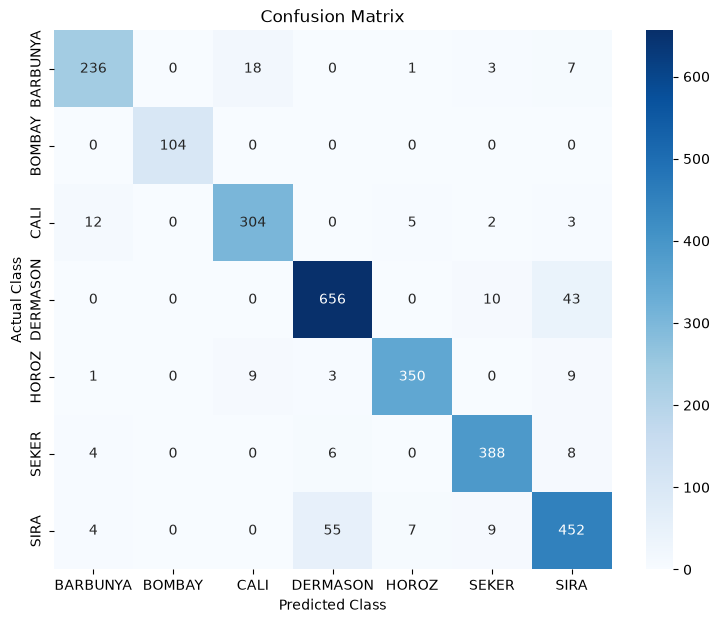

In [38]:
cm = confusion_matrix(
    y_test,
    y_test_pred_rf
)

plt.figure(figsize=(9, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=sorted(y.unique()),
    yticklabels=sorted(y.unique())
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix")

plt.show()

In [39]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [40]:
cv_scores_rf = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy"
)

print("CV Scores:", cv_scores_rf)

print(
    "Mean CV Accuracy:",
    cv_scores_rf.mean()
)

print(
    "CV Standard Deviation:",
    cv_scores_rf.std()
)

CV Scores: [0.92939548 0.91647439 0.91462852 0.922012   0.93259464]
Mean CV Accuracy: 0.9230210055047998
CV Standard Deviation: 0.00702279976529504


In [41]:
from imblearn.over_sampling import SMOTE

In [42]:
smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [43]:
print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
Class
DERMASON    2837
SIRA        2109
SEKER       1621
HOROZ       1488
CALI        1304
BARBUNYA    1057
BOMBAY       418
Name: count, dtype: int64

After SMOTE:
Class
CALI        2837
BARBUNYA    2837
HOROZ       2837
SIRA        2837
DERMASON    2837
SEKER       2837
BOMBAY      2837
Name: count, dtype: int64


In [44]:
rf_smote = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_smote.fit(
    X_train_smote,
    y_train_smote
)

y_test_pred_rf_smote = rf_smote.predict(X_test)

In [48]:
print(
    classification_report(
        y_test,
        y_test_pred_rf_smote
    )
)

              precision    recall  f1-score   support

    BARBUNYA       0.92      0.90      0.91       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.92      0.94      0.93       326
    DERMASON       0.92      0.91      0.91       709
       HOROZ       0.96      0.94      0.95       372
       SEKER       0.93      0.95      0.94       406
        SIRA       0.85      0.87      0.86       527

    accuracy                           0.92      2709
   macro avg       0.93      0.93      0.93      2709
weighted avg       0.92      0.92      0.92      2709



In [49]:
param_grid_rf = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

In [50]:
grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),
    param_grid=param_grid_rf,
    cv=cv,
    scoring="f1_weighted",
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 10, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevalua

In [51]:
print(
    "Best Parameters:"
)

print(
    grid_rf.best_params_
)

Best Parameters:
{'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 300}


In [52]:
print(
    "Best CV F1 Score:",
    grid_rf.best_score_
)

Best CV F1 Score: 0.9250869684441467


In [53]:
best_rf = grid_rf.best_estimator_

In [54]:
y_train_pred_best_rf = best_rf.predict(X_train)

y_test_pred_best_rf = best_rf.predict(X_test)

In [55]:
print("Training Accuracy:")

print(
    accuracy_score(
        y_train,
        y_train_pred_best_rf
    )
)

print("\nTesting Accuracy:")

print(
    accuracy_score(
        y_test,
        y_test_pred_best_rf
    )
)

Training Accuracy:
0.9852316780505815

Testing Accuracy:
0.9213732004429679


In [56]:
print(
    classification_report(
        y_test,
        y_test_pred_best_rf
    )
)

              precision    recall  f1-score   support

    BARBUNYA       0.94      0.89      0.92       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.92      0.94      0.93       326
    DERMASON       0.91      0.92      0.92       709
       HOROZ       0.96      0.95      0.96       372
       SEKER       0.94      0.96      0.95       406
        SIRA       0.87      0.86      0.87       527

    accuracy                           0.92      2709
   macro avg       0.93      0.93      0.93      2709
weighted avg       0.92      0.92      0.92      2709



In [57]:
final_results = []

models_predictions = {
    "Logistic Regression": (
        y_train_pred_lr,
        y_test_pred_lr
    ),
    
    "Decision Tree": (
        y_train_pred_dt,
        y_test_pred_dt
    ),
    
    "Random Forest": (
        y_train_pred_rf,
        y_test_pred_rf
    ),
    
    "KNN": (
        y_train_pred_knn,
        y_test_pred_knn
    ),
    
    "SVM": (
        y_train_pred_svm,
        y_test_pred_svm
    ),
    
    "Naive Bayes": (
        y_train_pred_nb,
        y_test_pred_nb
    ),
    
    "Gradient Boosting": (
        y_train_pred_gb,
        y_test_pred_gb
    )
}

In [58]:
for model_name, predictions in models_predictions.items():
    
    train_pred = predictions[0]
    test_pred = predictions[1]
    
    train_accuracy = accuracy_score(
        y_train,
        train_pred
    )
    
    test_accuracy = accuracy_score(
        y_test,
        test_pred
    )
    
    f1 = f1_score(
        y_test,
        test_pred,
        average="weighted"
    )
    
    gap = train_accuracy - test_accuracy
    
    final_results.append({
        "Model": model_name,
        "Train Accuracy": train_accuracy,
        "Test Accuracy": test_accuracy,
        "F1 Score": f1,
        "Accuracy Gap": gap,
        "Overfitting": "Y" if gap > 0.05 else "N"
    })

In [59]:
comparison_df = pd.DataFrame(final_results)

comparison_df.sort_values(
    by="Test Accuracy",
    ascending=False
)

,Model,Train Accuracy,Test Accuracy,F1 Score,Accuracy Gap,Overfitting
4,SVM,0.934189,0.921004,0.921078,0.013185,N
0,Logistic Regression,0.926158,0.919528,0.919667,0.006631,N
2,Random Forest,1.000000,0.919158,0.919102,0.080842,Y
6,Gradient Boosting,0.964002,0.918420,0.918393,0.045582,N
3,KNN,0.942404,0.915467,0.915652,0.026937,N
1,Decision Tree,1.000000,0.895533,0.895289,0.104467,Y
5,Naive Bayes,0.763799,0.763012,0.760651,0.000787,N


In [60]:
voting_model = VotingClassifier(
    estimators=[
        ("lr", LogisticRegression(max_iter=2000)),
        ("rf", RandomForestClassifier(
            n_estimators=200,
            random_state=42
        )),
        ("knn", KNeighborsClassifier())
    ],
    voting="hard"
)

In [61]:
voting_model.fit(
    X_train,
    y_train
)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('lr', ...), ('rf', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'hard'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels.","ndarray[object](7,)","['BARBUNYA','BOMBAY','CALI',...,'HOROZ','SEKER','SIRA']"
"estimators_ estimators_: list of classifiersThe collection of fitted sub-estimators as defined in ``estimators``that are not 'drop'. Note that sub-estimators are always fitted oninteger-encoded labels (see ``le_`` attribute). When ``y`` containsnon-integer class labels (e.g. strings), use ``le_.inverse_transform``to map predictions back to the original label space.",list,"[LogisticRegre...max_iter=2000), RandomForestC...ndom_state=42), KNeighborsClassifier()]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimators expose such an attribute when fit... versionadded:: 1.0","ndarray[object](16,)","['Area','Perimeter','MajorAxisLength',...,'ShapeFactor2','ShapeFactor3', 'ShapeFactor4']"
le_ le_: :class:`~sklearn.preprocessing.LabelEncoder`Transformer used to encode the labels during fit and decode duringprediction. Sub-estimators in ``estimators_`` are fitted on theinteger-encoded labels produced by this encoder.,LabelEncoder,LabelEncoder()


In [62]:
y_test_pred_voting = voting_model.predict(
    X_test
)

In [63]:
print(
    classification_report(
        y_test,
        y_test_pred_voting
    )
)

              precision    recall  f1-score   support

    BARBUNYA       0.90      0.87      0.88       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.90      0.94      0.92       326
    DERMASON       0.89      0.92      0.91       709
       HOROZ       0.96      0.93      0.94       372
       SEKER       0.93      0.92      0.93       406
        SIRA       0.86      0.84      0.85       527

    accuracy                           0.91      2709
   macro avg       0.92      0.92      0.92      2709
weighted avg       0.91      0.91      0.91      2709



In [64]:
import joblib

joblib.dump(
    best_rf,
    "dry_bean_classifier.pkl"
)

['dry_bean_classifier.pkl']